# IMPORT LIBRARIES

In [3]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# IMPORT DATA

In [16]:
import json
import os
import re
import matplotlib.pyplot as plt

# -------------------------------------------------
# BASE FOLDERS
# -------------------------------------------------
results_dir = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results"
instances_dir = r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances"

# -------------------------------------------------
# EXTRACT METRICS FROM JSON
# -------------------------------------------------
def get_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    L = vars_dict.get("L", {})
    idle = vars_dict.get("idle_away", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle),
        "lateness": sum(float(v) for v in L.values()) if L else 0.0,
    }

# -------------------------------------------------
# FIND MATCHING FILE PAIRS BY SEED
# expected names:
#   economic_baseline_seed10.json
#   sustainability_aware_seed10.json
#   demo_clustered_seed10.json
# -------------------------------------------------
all_result_files = os.listdir(results_dir)
all_instance_files = os.listdir(instances_dir)

economic_files = {}
sustain_files = {}
instance_files = {}

for fname in all_result_files:
    econ_match = re.match(r"economic_baseline_seed(\d+)\.json$", fname)
    sust_match = re.match(r"sustainability_aware_seed(\d+)\.json$", fname)

    if econ_match:
        seed = econ_match.group(1)
        economic_files[seed] = fname

    if sust_match:
        seed = sust_match.group(1)
        sustain_files[seed] = fname

for fname in all_instance_files:
    inst_match = re.match(r"demo_clustered_seed(\d+)\.json$", fname)
    if inst_match:
        seed = inst_match.group(1)
        instance_files[seed] = fname

# seeds that exist in all three folders/groups
common_seeds = sorted(
    set(economic_files.keys()) & set(sustain_files.keys()) & set(instance_files.keys()),
    key=int
)

if not common_seeds:
    raise FileNotFoundError(
        "No matching triplets found:\n"
        "  economic_baseline_seedX.json\n"
        "  sustainability_aware_seedX.json\n"
        "  demo_clustered_seedX.json"
    )

print("Matched triplets:")
for seed in common_seeds:
    print(
        f"Seed {seed}: "
        f"{economic_files[seed]}  <->  "
        f"{sustain_files[seed]}  <->  "
        f"{instance_files[seed]}"
    )

Matched triplets:
Seed 10: economic_baseline_seed10.json  <->  sustainability_aware_seed10.json  <->  demo_clustered_seed10.json


# ANALYZE

## OBJECTIVE FUNCTIONS

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json

Seed-level % differences:
   work_days  travel_moves  hotel_days  idle_away_days  lateness
0      -0.75        -52.66      -100.0          -100.0    366.67

Duration sensitivity correlation:
          work_days  travel_moves  hotel_days  idle_away_days  lateness
Mean dur        NaN           NaN         NaN             NaN       NaN
Std dur         NaN           NaN         NaN             NaN       NaN

Distance sensitivity correlation:
           work_days  travel_moves  hotel_days  idle_away_days  lateness
Mean dist        NaN           NaN         NaN             NaN       NaN
Std dist         NaN           NaN         NaN             NaN       NaN


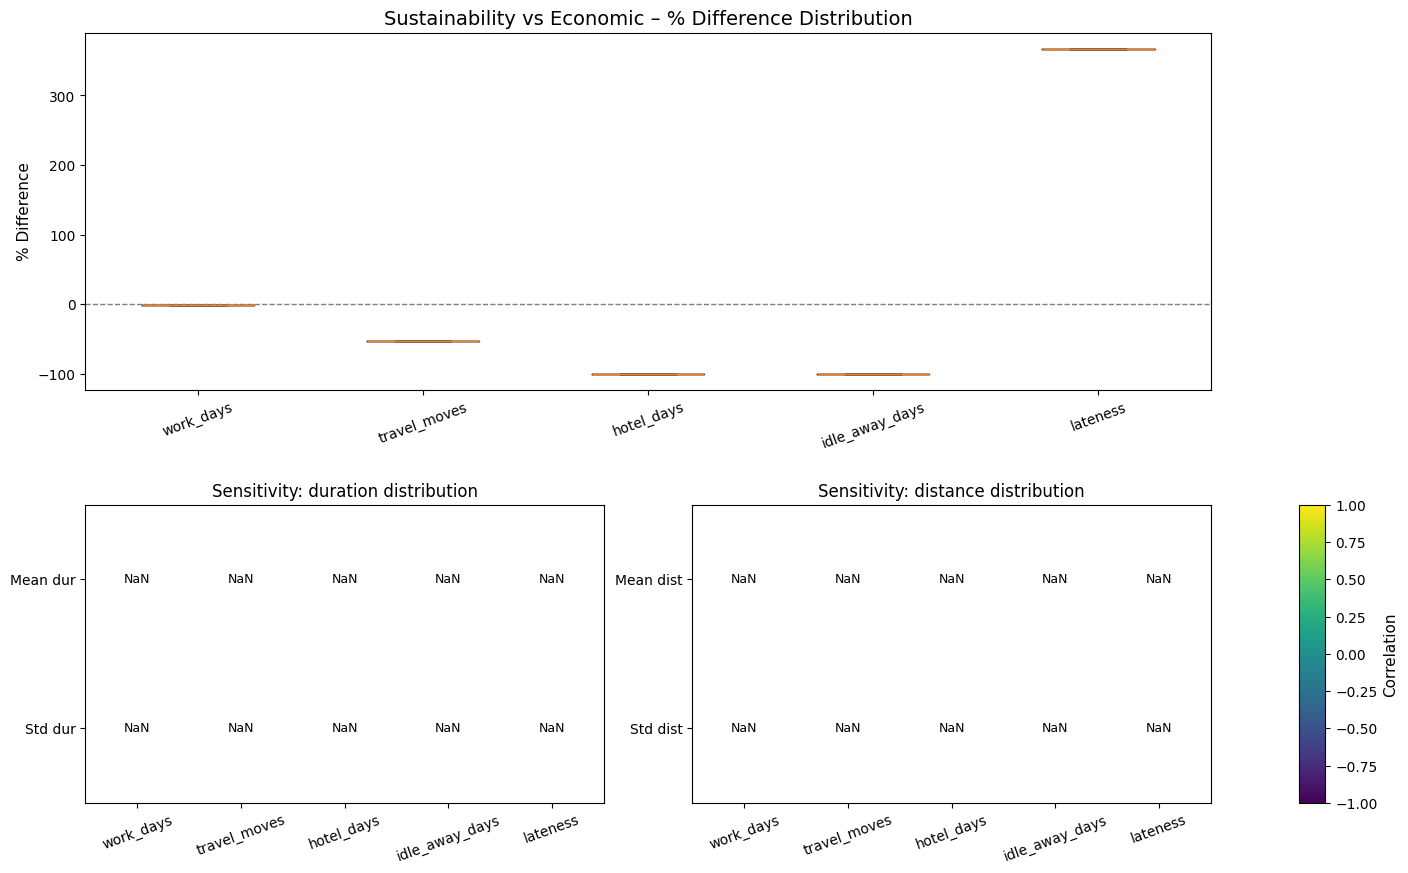

In [20]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# BASIC UTILITIES
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def safe_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


# =================================================
# FILE MATCHING
# =================================================
def collect_seed_files(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# SOLUTION METRICS
# =================================================
def extract_solution_metrics(vars_dict):
    z = vars_dict.get("z", {})
    y = vars_dict.get("y", {})
    hotel = vars_dict.get("hotel", {})
    idle_away = vars_dict.get("idle_away", {})
    lateness = vars_dict.get("L", {})

    return {
        "work_days": len(z),
        "travel_moves": len(y),
        "hotel_days": len(hotel),
        "idle_away_days": len(idle_away),
        "lateness": sum(float(v) for v in lateness.values()) if lateness else 0.0,
    }


def compute_percentage_change(econ_value, sust_value):
    econ_value = float(econ_value)
    sust_value = float(sust_value)

    if abs(econ_value) < 1e-12:
        return np.nan

    return 100.0 * (sust_value - econ_value) / econ_value


# =================================================
# TECHNICIAN FEATURES
# =================================================
def technician_duration_lists(start_dict, dur_map):
    tech_to_durations = {}

    for key, val in start_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)   # t | k | d
        if parts is None:
            continue

        task, tech, _day = parts
        dur_key = f"{task}|{tech}"
        duration = dur_map.get(dur_key)

        if duration is None or duration == 999:
            continue

        tech_to_durations.setdefault(tech, []).append(float(duration))

    return tech_to_durations


def technician_distance_lists(move_dict, dist_map):
    tech_to_distances = {}

    for key, val in move_dict.items():
        if float(val) <= 0.5:
            continue

        parts = split_key(key, expected_len=5)   # i | j | k | d | m
        if parts is None:
            continue

        origin, destination, tech, _day, _mode = parts
        dist_key = f"{origin}|{destination}"
        distance = dist_map.get(dist_key)

        if distance is None:
            continue

        tech_to_distances.setdefault(tech, []).append(float(distance))

    return tech_to_distances


def summarize_list(values):
    if not values:
        return np.nan, np.nan
    if len(values) == 1:
        return float(np.mean(values)), np.nan
    return float(np.mean(values)), float(np.std(values, ddof=1))


def build_technician_features(instance_data, econ_vars, sust_vars):
    dur_map = instance_data.get("dur", {})
    dist_map = instance_data.get("dist", {})
    tech_base = instance_data.get("base", {})
    technicians = sorted(tech_base.keys())

    econ_start = econ_vars.get("start", {})
    sust_start = sust_vars.get("start", {})
    econ_moves = econ_vars.get("y", {})
    sust_moves = sust_vars.get("y", {})

    econ_task_durations = technician_duration_lists(econ_start, dur_map)
    sust_task_durations = technician_duration_lists(sust_start, dur_map)

    econ_move_distances = technician_distance_lists(econ_moves, dist_map)
    sust_move_distances = technician_distance_lists(sust_moves, dist_map)

    rows = []
    for tech in technicians:
        econ_mean_dur, econ_std_dur = summarize_list(econ_task_durations.get(tech, []))
        sust_mean_dur, sust_std_dur = summarize_list(sust_task_durations.get(tech, []))

        econ_mean_dist, econ_std_dist = summarize_list(econ_move_distances.get(tech, []))
        sust_mean_dist, sust_std_dist = summarize_list(sust_move_distances.get(tech, []))

        rows.append({
            "tech": tech,
            "econ_mean_dur": econ_mean_dur,
            "econ_std_dur": econ_std_dur,
            "sust_mean_dur": sust_mean_dur,
            "sust_std_dur": sust_std_dur,
            "econ_mean_dist": econ_mean_dist,
            "econ_std_dist": econ_std_dist,
            "sust_mean_dist": sust_mean_dist,
            "sust_std_dist": sust_std_dist,
        })

    return pd.DataFrame(rows)


# =================================================
# BUILD TABLES
# =================================================
def build_analysis_tables(common_seeds, economic_files, sustainability_files, instance_files):
    seed_rows = []
    tech_frames = []

    metrics = ["work_days", "travel_moves", "hotel_days", "idle_away_days", "lateness"]

    for seed in common_seeds:
        econ_data = load_json(economic_files[seed])
        sust_data = load_json(sustainability_files[seed])
        inst_data = load_json(instance_files[seed])

        econ_vars = safe_variables(econ_data)
        sust_vars = safe_variables(sust_data)

        econ_metrics = extract_solution_metrics(econ_vars)
        sust_metrics = extract_solution_metrics(sust_vars)

        seed_row = {"seed": int(seed)}
        for metric in metrics:
            econ_value = econ_metrics[metric]
            sust_value = sust_metrics[metric]

            seed_row[f"econ_{metric}"] = econ_value
            seed_row[f"sust_{metric}"] = sust_value
            seed_row[f"diff_pct_{metric}"] = compute_percentage_change(econ_value, sust_value)

        seed_rows.append(seed_row)

        tech_df = build_technician_features(inst_data, econ_vars, sust_vars)
        tech_df["seed"] = int(seed)

        for metric in metrics:
            tech_df[f"diff_pct_{metric}"] = seed_row[f"diff_pct_{metric}"]

        tech_frames.append(tech_df)

    seed_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)
    tech_df = pd.concat(tech_frames, ignore_index=True)

    diff_pct = seed_df[[f"diff_pct_{m}" for m in metrics]].copy()
    diff_pct.columns = metrics

    return metrics, seed_df, tech_df, diff_pct


# =================================================
# CORRELATION MATRICES
# =================================================
def build_correlation_matrices(metrics, tech_df):
    tech_df = tech_df.copy()

    tech_df["delta_mean_dur"] = tech_df["sust_mean_dur"] - tech_df["econ_mean_dur"]
    tech_df["delta_std_dur"] = tech_df["sust_std_dur"] - tech_df["econ_std_dur"]
    tech_df["delta_mean_dist"] = tech_df["sust_mean_dist"] - tech_df["econ_mean_dist"]
    tech_df["delta_std_dist"] = tech_df["sust_std_dist"] - tech_df["econ_std_dist"]

    dur_corr = pd.DataFrame(index=["Mean dur", "Std dur"], columns=metrics, dtype=float)
    dist_corr = pd.DataFrame(index=["Mean dist", "Std dist"], columns=metrics, dtype=float)

    for metric in metrics:
        x = tech_df[f"diff_pct_{metric}"]

        dur_corr.loc["Mean dur", metric] = safe_corr(x, tech_df["delta_mean_dur"])
        dur_corr.loc["Std dur", metric] = safe_corr(x, tech_df["delta_std_dur"])

        dist_corr.loc["Mean dist", metric] = safe_corr(x, tech_df["delta_mean_dist"])
        dist_corr.loc["Std dist", metric] = safe_corr(x, tech_df["delta_std_dist"])

    return dur_corr, dist_corr


# =================================================
# PLOT
# =================================================
def annotate_heatmap(ax, df):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            value = df.iloc[i, j]
            text = "NaN" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=9)


def plot_results(metrics, diff_pct, dur_corr, dist_corr):
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.2, 1.0],
        width_ratios=[1, 1, 0.05],
        hspace=0.35,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    box_data = [diff_pct[m].dropna().values for m in metrics]
    ax_top.boxplot(box_data, labels=metrics)
    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")

    ax_top.set_title("Sustainability vs Economic – % Difference Distribution", fontsize=14)
    ax_top.set_ylabel("% Difference", fontsize=11)
    ax_top.tick_params(axis="x", rotation=20)

    # ---------------- BOTTOM LEFT: DURATION ----------------
    ax_left = fig.add_subplot(gs[1, 0])
    im_left = ax_left.imshow(dur_corr.values.astype(float), vmin=-1, vmax=1, aspect="auto")

    ax_left.set_xticks(np.arange(len(metrics)))
    ax_left.set_xticklabels(metrics, rotation=20)
    ax_left.set_yticks(np.arange(len(dur_corr.index)))
    ax_left.set_yticklabels(dur_corr.index)
    ax_left.set_title("Sensitivity: duration distribution", fontsize=12)

    annotate_heatmap(ax_left, dur_corr)

    # ---------------- BOTTOM RIGHT: DISTANCE ----------------
    ax_right = fig.add_subplot(gs[1, 1])
    im_right = ax_right.imshow(dist_corr.values.astype(float), vmin=-1, vmax=1, aspect="auto")

    ax_right.set_xticks(np.arange(len(metrics)))
    ax_right.set_xticklabels(metrics, rotation=20)
    ax_right.set_yticks(np.arange(len(dist_corr.index)))
    ax_right.set_yticklabels(dist_corr.index)
    ax_right.set_title("Sensitivity: distance distribution", fontsize=12)

    annotate_heatmap(ax_right, dist_corr)

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1, 2])
    cbar = fig.colorbar(im_right, cax=cax)
    cbar.set_label("Correlation", fontsize=11)

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_seed_files(
    RESULTS_DIR,
    INSTANCES_DIR
)

metrics, seed_df, tech_df, diff_pct = build_analysis_tables(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

dur_corr, dist_corr = build_correlation_matrices(metrics, tech_df)

print("\nSeed-level % differences:")
print(diff_pct.round(2))

print("\nDuration sensitivity correlation:")
print(dur_corr.round(3))

print("\nDistance sensitivity correlation:")
print(dist_corr.round(3))

plot_results(metrics, diff_pct, dur_corr, dist_corr)

## TRAVEL MODE

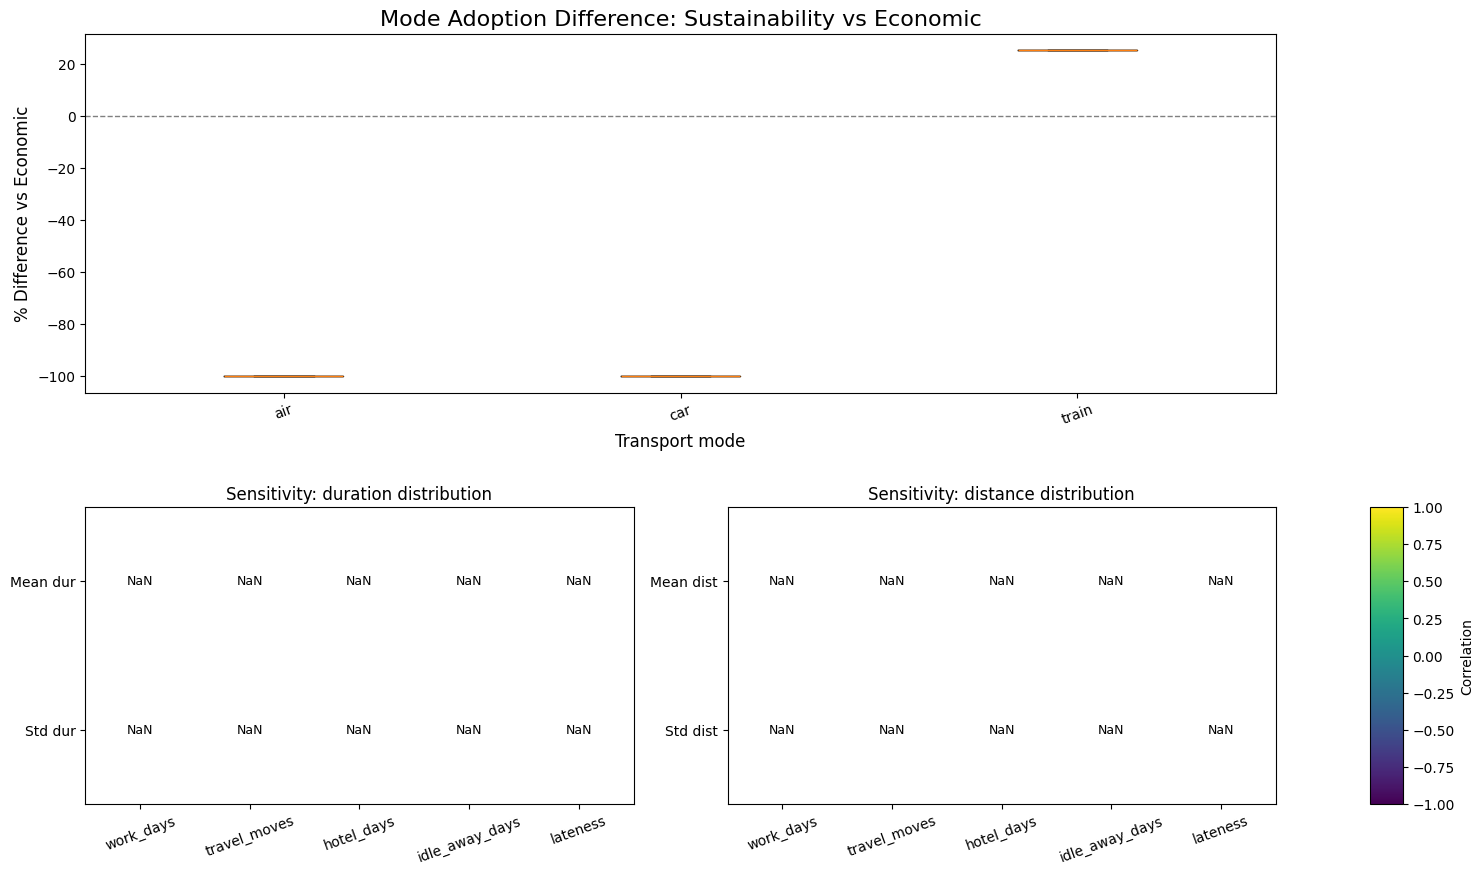

In [23]:
# =================================================
# PREPARE DATA FOR MODE ANALYSIS
# =================================================

def extract_modes_from_vars(vars_dict):
    """Extract transport modes used in y variables"""
    modes = set()
    for key in vars_dict.get("y", {}):
        parts = str(key).split("|")
        if len(parts) == 5:
            modes.add(parts[4])  # mode is last element
    return modes


def compute_mode_usage(vars_dict):
    """Count usage of each mode"""
    usage = {}
    for key, val in vars_dict.get("y", {}).items():
        if float(val) <= 0.5:
            continue
        parts = str(key).split("|")
        if len(parts) != 5:
            continue
        mode = parts[4]
        usage[mode] = usage.get(mode, 0) + 1
    return usage


# -------------------------------------------------
# BUILD MODE DIFFERENCES ACROSS SEEDS
# -------------------------------------------------
mode_diffs = {}

for seed in common_seeds:
    econ_data = load_json(economic_files[seed])
    sust_data = load_json(sustainability_files[seed])

    econ_vars = safe_variables(econ_data)
    sust_vars = safe_variables(sust_data)

    econ_usage = compute_mode_usage(econ_vars)
    sust_usage = compute_mode_usage(sust_vars)

    all_modes = set(econ_usage) | set(sust_usage)

    for mode in all_modes:
        e = econ_usage.get(mode, 0)
        s = sust_usage.get(mode, 0)

        if e == 0:
            diff = np.nan
        else:
            diff = 100.0 * (s - e) / e

        mode_diffs.setdefault(mode, []).append(diff)

# -------------------------------------------------
# FINAL DATA FOR PLOT
# -------------------------------------------------
valid_modes = sorted(mode_diffs.keys())
boxplot_data = [np.array(mode_diffs[m], dtype=float) for m in valid_modes]

# =================================================
# FIGURE
# =================================================
fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1.15, 0.95],
    width_ratios=[1, 1, 0.06],
    hspace=0.35,
    wspace=0.25
)

# ---------------- TOP: BOXPLOT ----------------
ax_top = fig.add_subplot(gs[0, :2])

clean_data = []
clean_labels = []

for mode, values in zip(valid_modes, boxplot_data):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        continue
    clean_data.append(arr)
    clean_labels.append(mode)

if not clean_data:
    raise ValueError("No valid mode data available.")

ax_top.boxplot(clean_data, labels=clean_labels)
ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")

ylabel = "% Difference vs Economic"
ax_top.set_ylabel(ylabel, fontsize=12)
ax_top.set_xlabel("Transport mode", fontsize=12)
ax_top.set_title("Mode Adoption Difference: Sustainability vs Economic", fontsize=16)
ax_top.tick_params(axis="x", rotation=20)

# ---------------- BOTTOM LEFT ----------------
ax1 = fig.add_subplot(gs[1, 0])

im1 = ax1.imshow(dur_corr.values.astype(float), vmin=-1, vmax=1, aspect="auto")

ax1.set_xticks(np.arange(len(dur_corr.columns)))
ax1.set_xticklabels(dur_corr.columns, rotation=20)
ax1.set_yticks(np.arange(len(dur_corr.index)))
ax1.set_yticklabels(dur_corr.index)
ax1.set_title("Sensitivity: duration distribution")

for i in range(dur_corr.shape[0]):
    for j in range(dur_corr.shape[1]):
        v = dur_corr.iloc[i, j]
        txt = "NaN" if pd.isna(v) else f"{v:.2f}"
        ax1.text(j, i, txt, ha="center", va="center", fontsize=9)

# ---------------- BOTTOM RIGHT ----------------
ax2 = fig.add_subplot(gs[1, 1])

im2 = ax2.imshow(dist_corr.values.astype(float), vmin=-1, vmax=1, aspect="auto")

ax2.set_xticks(np.arange(len(dist_corr.columns)))
ax2.set_xticklabels(dist_corr.columns, rotation=20)
ax2.set_yticks(np.arange(len(dist_corr.index)))
ax2.set_yticklabels(dist_corr.index)
ax2.set_title("Sensitivity: distance distribution")

for i in range(dist_corr.shape[0]):
    for j in range(dist_corr.shape[1]):
        v = dist_corr.iloc[i, j]
        txt = "NaN" if pd.isna(v) else f"{v:.2f}"
        ax2.text(j, i, txt, ha="center", va="center", fontsize=9)

# ---------------- COLORBAR ----------------
cax = fig.add_subplot(gs[1, 2])
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("Correlation")

plt.show()

## TECHNICIAN CHOICHE

Matched triplets:
Seed 10: economic_baseline_seed10.json <-> sustainability_aware_seed10.json <-> demo_clustered_seed10.json

Seed 10 - percentage composition:
category  Both  Only most skilled  Only closest  Neither
scenario                                                
ECO       68.0               12.0          16.0      4.0
SUST      80.0                2.0          18.0      0.0

Per-seed dataset:
   seed  mean_dur  std_dur  mean_dist  std_dist  Both  Only most skilled  \
0    10     2.859     1.37     155.08    91.538  12.0              -10.0   

   Only closest  Neither  
0           2.0     -4.0  

Differences by category:
Both: [12.0]
Only most skilled: [-10.0]
Only closest: [2.0]
Neither: [-4.0]

Correlation matrix - dur features:
          Both  Only most skilled  Only closest  Neither
mean_dur   NaN                NaN           NaN      NaN
std_dur    NaN                NaN           NaN      NaN

Correlation matrix - dist features:
           Both  Only most skilled  Only

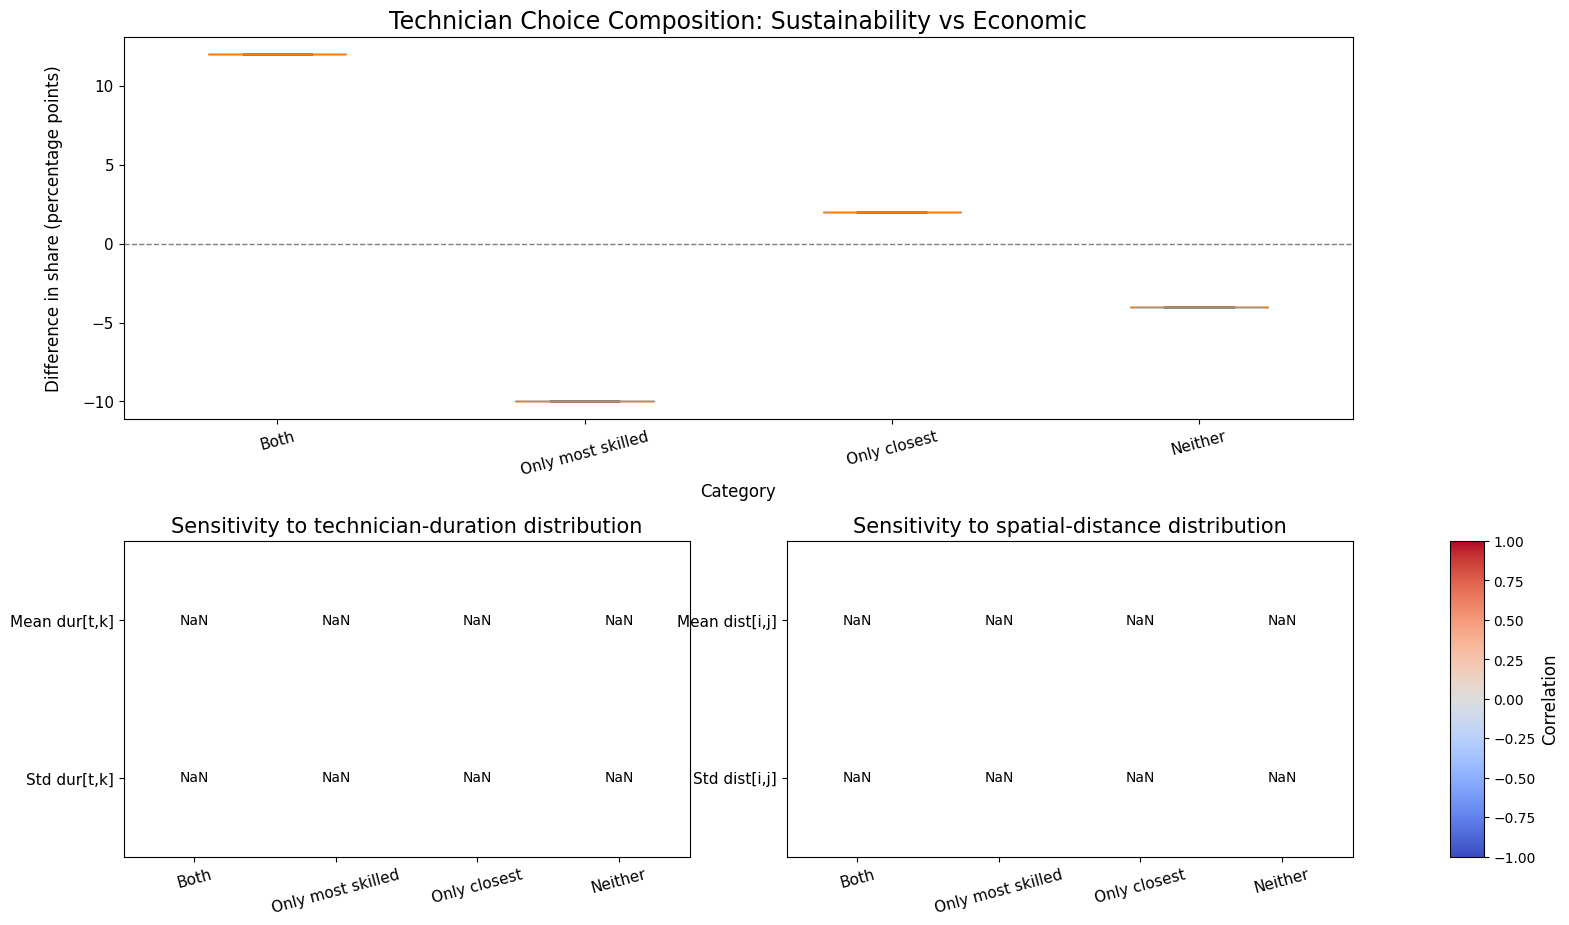

In [25]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =================================================
# PATHS
# =================================================
RESULTS_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\results")
INSTANCES_DIR = Path(r"G:\Il mio Drive\LAVORO\1.RICERCA\0.CONFERENCE PAPER\4.KES\2026\1.CODE\instances")


# =================================================
# SETTINGS
# =================================================
USE_PERCENTAGE_POINTS = True
CATEGORY_ORDER = ["Both", "Only most skilled", "Only closest", "Neither"]


# =================================================
# BASIC HELPERS
# =================================================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_key(key, expected_len=None):
    parts = str(key).split("|")
    if expected_len is not None and len(parts) != expected_len:
        return None
    return parts


def get_variables(data):
    return data.get("variables", {})


def safe_corr(x, y):
    x = pd.Series(x, dtype=float)
    y = pd.Series(y, dtype=float)

    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan

    return x.corr(y)


def get_nested_or_flat(data_dict, key1, key2, default=np.nan):
    if isinstance(data_dict.get(key1), dict) and key2 in data_dict[key1]:
        return float(data_dict[key1][key2])

    flat_key = f"{key1}|{key2}"
    if flat_key in data_dict:
        return float(data_dict[flat_key])

    return default


# =================================================
# MATCH FILES BY SEED
# =================================================
def collect_triplets(results_dir, instances_dir):
    economic_files = {}
    sustainability_files = {}
    instance_files = {}

    for path in results_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"economic_baseline_seed(\d+)\.json", path.name)
        if m:
            economic_files[m.group(1)] = path
            continue

        m = re.fullmatch(r"sustainability_aware_seed(\d+)\.json", path.name)
        if m:
            sustainability_files[m.group(1)] = path

    for path in instances_dir.iterdir():
        if not path.is_file():
            continue

        m = re.fullmatch(r"demo_clustered_seed(\d+)\.json", path.name)
        if m:
            instance_files[m.group(1)] = path

    common_seeds = sorted(
        set(economic_files) & set(sustainability_files) & set(instance_files),
        key=int
    )

    if not common_seeds:
        raise FileNotFoundError(
            "No matching triplets found:\n"
            "  economic_baseline_seedX.json\n"
            "  sustainability_aware_seedX.json\n"
            "  demo_clustered_seedX.json"
        )

    print("Matched triplets:")
    for seed in common_seeds:
        print(
            f"Seed {seed}: "
            f"{economic_files[seed].name} <-> "
            f"{sustainability_files[seed].name} <-> "
            f"{instance_files[seed].name}"
        )

    return common_seeds, economic_files, sustainability_files, instance_files


# =================================================
# CHOSEN TECHNICIAN
# =================================================
def get_chosen_technician(result_variables):
    chosen = {}
    start = result_variables.get("start", {})

    for key, value in start.items():
        if float(value) <= 0.5:
            continue

        parts = split_key(key, expected_len=3)  # ticket | tech | day
        if parts is None:
            continue

        ticket, tech, _day = parts
        chosen[ticket] = tech

    return chosen


# =================================================
# CLASSIFICATION
# =================================================
def classify_choice(chosen_tech, best_skill_set, closest_set):
    is_most_skilled = chosen_tech in best_skill_set
    is_closest = chosen_tech in closest_set

    if is_most_skilled and is_closest:
        return "Both"
    if is_most_skilled:
        return "Only most skilled"
    if is_closest:
        return "Only closest"
    return "Neither"


# =================================================
# INSTANCE FEATURES
# =================================================
def extract_instance_features(instance):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    nodes = list(instance.get("N", []))

    dur_data = instance.get("dur", {})
    dist_data = instance.get("dist", {})

    dur_vals = []
    for t in tickets:
        for k in technicians:
            val = get_nested_or_flat(dur_data, t, k, default=np.nan)
            if not pd.isna(val) and val != 999:
                dur_vals.append(float(val))

    dist_vals = []
    for i in nodes:
        for j in nodes:
            val = get_nested_or_flat(dist_data, i, j, default=np.nan)
            if not pd.isna(val):
                dist_vals.append(float(val))

    return {
        "mean_dur": float(np.mean(dur_vals)) if dur_vals else np.nan,
        "std_dur": float(np.std(dur_vals, ddof=1)) if len(dur_vals) >= 2 else np.nan,
        "mean_dist": float(np.mean(dist_vals)) if dist_vals else np.nan,
        "std_dist": float(np.std(dist_vals, ddof=1)) if len(dist_vals) >= 2 else np.nan,
    }


# =================================================
# PER-SEED CATEGORY DIFFERENCES
# =================================================
def compute_seed_category_differences(instance, econ_vars, sust_vars, use_percentage_points=True):
    tickets = list(instance.get("T", []))
    technicians = list(instance.get("K", []))
    ticket_node_map = instance.get("node", {})
    tech_base_map = instance.get("base", {})
    dist_data = instance.get("dist", {})
    dur_data = instance.get("dur", {})

    econ_choice = get_chosen_technician(econ_vars)
    sust_choice = get_chosen_technician(sust_vars)

    records = []

    for ticket in tickets:
        ticket_node = ticket_node_map.get(ticket)
        if ticket_node is None:
            continue

        skill_values = []
        distance_values = []

        for tech in technicians:
            tech_base = tech_base_map.get(tech)
            if tech_base is None:
                continue

            dur_val = get_nested_or_flat(dur_data, ticket, tech, default=np.nan)
            dist_val = get_nested_or_flat(dist_data, tech_base, ticket_node, default=np.nan)

            if not pd.isna(dur_val) and dur_val != 999:
                skill_values.append((tech, float(dur_val)))

            if not pd.isna(dist_val):
                distance_values.append((tech, float(dist_val)))

        if not skill_values or not distance_values:
            continue

        best_skill_value = min(v for _, v in skill_values)
        closest_value = min(v for _, v in distance_values)

        best_skill_set = {tech for tech, v in skill_values if abs(v - best_skill_value) <= 1e-9}
        closest_set = {tech for tech, v in distance_values if abs(v - closest_value) <= 1e-9}

        for scenario_name, scenario_choice in [("ECO", econ_choice), ("SUST", sust_choice)]:
            chosen_tech = scenario_choice.get(ticket)
            if chosen_tech is None:
                continue

            category = classify_choice(chosen_tech, best_skill_set, closest_set)

            records.append({
                "scenario": scenario_name,
                "ticket": ticket,
                "category": category
            })

    df = pd.DataFrame(records)

    if df.empty:
        return None, None, None

    summary_counts = (
        df.groupby(["scenario", "category"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=["ECO", "SUST"], columns=CATEGORY_ORDER, fill_value=0)
    )

    summary_pct = summary_counts.div(summary_counts.sum(axis=1), axis=0) * 100.0

    diff_map = {}
    for cat in CATEGORY_ORDER:
        eco_val = summary_pct.loc["ECO", cat]
        sust_val = summary_pct.loc["SUST", cat]

        if use_percentage_points:
            diff = sust_val - eco_val
        else:
            diff = np.nan if abs(eco_val) < 1e-12 else (sust_val - eco_val) / eco_val * 100.0

        diff_map[cat] = diff

    return df, summary_pct, diff_map


# =================================================
# BUILD DATASET
# =================================================
def build_pair_dataset(common_seeds, economic_files, sustainability_files, instance_files):
    rows = []
    diff_by_category = {cat: [] for cat in CATEGORY_ORDER}

    for seed in common_seeds:
        econ = load_json(economic_files[seed])
        sust = load_json(sustainability_files[seed])
        instance = load_json(instance_files[seed])

        econ_vars = get_variables(econ)
        sust_vars = get_variables(sust)

        features = extract_instance_features(instance)

        detail_df, summary_pct, diff_map = compute_seed_category_differences(
            instance,
            econ_vars,
            sust_vars,
            use_percentage_points=USE_PERCENTAGE_POINTS
        )

        if detail_df is None or summary_pct is None or diff_map is None:
            print(f"Seed {seed}: no assignments found, skipped.")
            continue

        print(f"\nSeed {seed} - percentage composition:")
        print(summary_pct.round(2))

        row = {"seed": int(seed)}
        row.update(features)

        for cat in CATEGORY_ORDER:
            row[cat] = diff_map[cat]
            if not pd.isna(diff_map[cat]):
                diff_by_category[cat].append(diff_map[cat])

        rows.append(row)

    pair_df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

    if pair_df.empty:
        raise ValueError("No valid pair data available.")

    return pair_df, diff_by_category


# =================================================
# CORRELATION MATRICES
# =================================================
def build_correlation_matrices(pair_df, valid_categories):
    dur_features = ["mean_dur", "std_dur"]
    dist_features = ["mean_dist", "std_dist"]

    dur_corr = pd.DataFrame(index=dur_features, columns=valid_categories, dtype=float)
    dist_corr = pd.DataFrame(index=dist_features, columns=valid_categories, dtype=float)

    for feat in dur_features:
        for cat in valid_categories:
            dur_corr.loc[feat, cat] = safe_corr(pair_df[feat], pair_df[cat])

    for feat in dist_features:
        for cat in valid_categories:
            dist_corr.loc[feat, cat] = safe_corr(pair_df[feat], pair_df[cat])

    return dur_corr, dist_corr


# =================================================
# HEATMAP ANNOTATION
# =================================================
def annotate_heatmap(ax, df, fontsize=10):
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iloc[i, j]
            txt = "NaN" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=fontsize)


# =================================================
# PLOT
# =================================================
def plot_results(valid_categories, boxplot_data, dur_corr, dist_corr):
    fig = plt.figure(figsize=(17, 10))
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[1.15, 0.95],
        width_ratios=[1, 1, 0.06],
        hspace=0.35,
        wspace=0.25
    )

    # ---------------- TOP: BOXPLOT ----------------
    ax_top = fig.add_subplot(gs[0, :2])

    clean_data = []
    clean_labels = []

    for cat, values in zip(valid_categories, boxplot_data):
        arr = np.asarray(values, dtype=float)
        arr = arr[~np.isnan(arr)]
        if arr.size == 0:
            continue
        clean_data.append(arr)
        clean_labels.append(cat)

    if not clean_data:
        raise ValueError("No valid category differences available for boxplot.")

    ax_top.boxplot(clean_data, labels=clean_labels, patch_artist=True)
    ax_top.axhline(0, linestyle="--", linewidth=1, color="gray")

    ylabel = (
        "Difference in share (percentage points)"
        if USE_PERCENTAGE_POINTS
        else "% Difference vs Economic"
    )

    ax_top.set_ylabel(ylabel, fontsize=12, labelpad=14)
    ax_top.set_xlabel("Category", fontsize=12)
    ax_top.set_title("Technician Choice Composition: Sustainability vs Economic", fontsize=17)
    ax_top.tick_params(axis="x", rotation=15, labelsize=11)
    ax_top.tick_params(axis="y", labelsize=11)

    # ---------------- BOTTOM LEFT: DUR ----------------
    ax1 = fig.add_subplot(gs[1, 0])

    dur_plot = dur_corr.astype(float)
    im1 = ax1.imshow(dur_plot.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax1.set_xticks(np.arange(dur_plot.shape[1]))
    ax1.set_xticklabels(list(dur_plot.columns), rotation=15, fontsize=11)
    ax1.set_yticks(np.arange(dur_plot.shape[0]))
    ax1.set_yticklabels(["Mean dur[t,k]", "Std dur[t,k]"], fontsize=11)
    ax1.set_title("Sensitivity to technician-duration distribution", fontsize=15)

    annotate_heatmap(ax1, dur_plot, fontsize=10)

    # ---------------- BOTTOM RIGHT: DIST ----------------
    ax2 = fig.add_subplot(gs[1, 1])

    dist_plot = dist_corr.astype(float)
    im2 = ax2.imshow(dist_plot.values, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
    ax2.set_xticks(np.arange(dist_plot.shape[1]))
    ax2.set_xticklabels(list(dist_plot.columns), rotation=15, fontsize=11)
    ax2.set_yticks(np.arange(dist_plot.shape[0]))
    ax2.set_yticklabels(["Mean dist[i,j]", "Std dist[i,j]"], fontsize=11)
    ax2.set_title("Sensitivity to spatial-distance distribution", fontsize=15)

    annotate_heatmap(ax2, dist_plot, fontsize=10)

    # ---------------- COLORBAR ----------------
    cax = fig.add_subplot(gs[1, 2])
    cbar = fig.colorbar(im2, cax=cax)
    cbar.set_label("Correlation", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    # ---------------- FINAL SPACING ----------------
    fig.subplots_adjust(
        left=0.12,
        right=0.92,
        top=0.92,
        bottom=0.10
    )

    plt.show()


# =================================================
# MAIN
# =================================================
common_seeds, economic_files, sustainability_files, instance_files = collect_triplets(
    RESULTS_DIR,
    INSTANCES_DIR
)

pair_df, diff_by_category = build_pair_dataset(
    common_seeds,
    economic_files,
    sustainability_files,
    instance_files
)

print("\nPer-seed dataset:")
print(pair_df.round(3))

valid_categories = [cat for cat in CATEGORY_ORDER if len(diff_by_category[cat]) > 0]
if not valid_categories:
    raise ValueError("No valid category differences could be computed.")

boxplot_data = [diff_by_category[cat] for cat in valid_categories]

print("\nDifferences by category:")
for cat in valid_categories:
    print(f"{cat}: {[round(v, 2) for v in diff_by_category[cat]]}")

dur_corr, dist_corr = build_correlation_matrices(pair_df, valid_categories)

print("\nCorrelation matrix - dur features:")
print(dur_corr.round(3))

print("\nCorrelation matrix - dist features:")
print(dist_corr.round(3))

plot_results(valid_categories, boxplot_data, dur_corr, dist_corr)